# EXtra-data template

This example reads two XGM photon-flux signals and plots them against each other. Replace the proposal and run numbers with your own data.

## Load and inspect the run

Open the run with `extra_data`, inspect its summary, and build a dataframe with the two XGM photon-flux signals.

In [ ]:
from extra_data import open_run
import matplotlib.pyplot as plt

In [1]:
proposal = 700000  # replace with your proposal
run_no = 1         # replace with your run number

run = open_run(proposal=proposal, run=run_no)
run.info()

xgm = run.select([('SA1_XTD2_XGM/*', 'pulseEnergy.photonFlux'), ('SPB_XTD9_XGM/*', 'pulseEnergy.photonFlux')])  # XGM = X-ray Gas Monitor
df = xgm.get_dataframe()
df = df.dropna()
df.head()


# of trains:    2426
Duration:       0:04:02.6
First train ID: 79498483
Last train ID:  79500908

16 XTDF detector modules of SPB_DET_AGIPD1M-1/DET/*
  e.g. module 0 : 512 x 128 pixels
  SPB_DET_AGIPD1M-1/DET/0CH0:xtdf
  64 frames per train, up to 155264 frames total

3 instrument sources (excluding XTDF detectors):
  - SA1_XTD2_XGM/XGM/DOOCS:output
  - SPB_IRU_SIDEMIC_CAM:daqOutput
  - SPB_XTD9_XGM/XGM/DOOCS:output

13 control sources:
  - ACC_SYS_DOOCS/CTRL/BEAMCONDITIONS
  - SA1_XTD2_XGM/XGM/DOOCS
  - SPB_IRU_AGIPD1M/PSC/HV
  - SPB_IRU_AGIPD1M/TSENS/H{1-2}_T_EXTHOUS
  - SPB_IRU_AGIPD1M/TSENS/Q{1-4}_T_BLOCK
  - SPB_IRU_AGIPD1M1/CTRL/MC{1-2}
  - SPB_IRU_VAC/GAUGE/GAUGE_FR_6
  - SPB_XTD9_XGM/XGM/DOOCS



,SPB_XTD9_XGM/XGM/DOOCS/pulseEnergy.photonFlux,SA1_XTD2_XGM/XGM/DOOCS/pulseEnergy.photonFlux
trainId,,
79498484,1024.435425,1019.683411
79498485,1024.435425,1019.683411
79498486,1024.435425,1019.233521
79498487,1024.435425,1019.233521
79498488,1024.435425,1019.233521


## Plot the photon fluxes

Plot the two XGM photon-flux signals against each other to inspect their correlation.

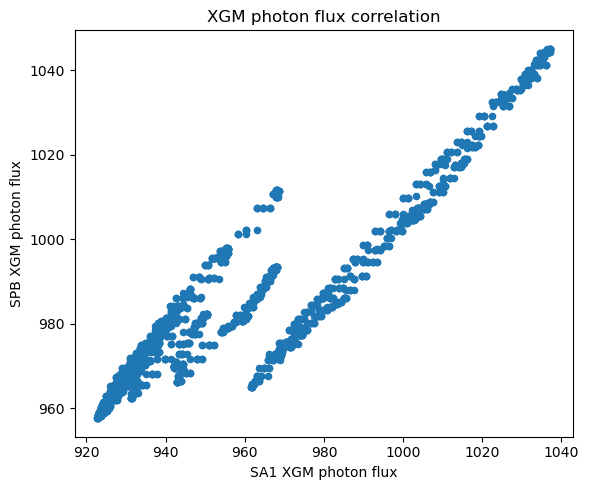

In [2]:
# Plot the photon fluxes against each other

ax = df.plot.scatter(
    x='SA1_XTD2_XGM/XGM/DOOCS/pulseEnergy.photonFlux',
    y='SPB_XTD9_XGM/XGM/DOOCS/pulseEnergy.photonFlux',
    figsize=(6, 5),
)
ax.set_title('XGM photon flux correlation')
ax.set_xlabel('SA1 XGM photon flux')
ax.set_ylabel('SPB XGM photon flux')
plt.tight_layout()

plt.show()
